<a href="https://colab.research.google.com/github/NatasaKinzy/Data-Science/blob/main/Unit7/NataKinzU7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

# Unit 7 Project



# Context

TotWT refers to total weight of octopus. UpBeak is the upper beak of the octopus, lo beak is the lower beak. Lateral wall is the wall on the side of the beak of the octopus and it's measured by its growth rings. A high latwall value is usually indicative of an older or larger individual. TotWt is likely measured in something larger than grams but smaller than kg because octopi are usually 18-50kg but I am not sure about the unit. Beaks are typically measured in mm so my guess is that is the case here. Larger beaks are generally associated with larger octopi.

# Purpose

I am going to try to predict TotWt with lobeak, upbeak, and latwall measurements.

# Data

In [2]:
url_oct = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv'
oct = pd.read_csv(url_oct).dropna()

In [ ]:
oct

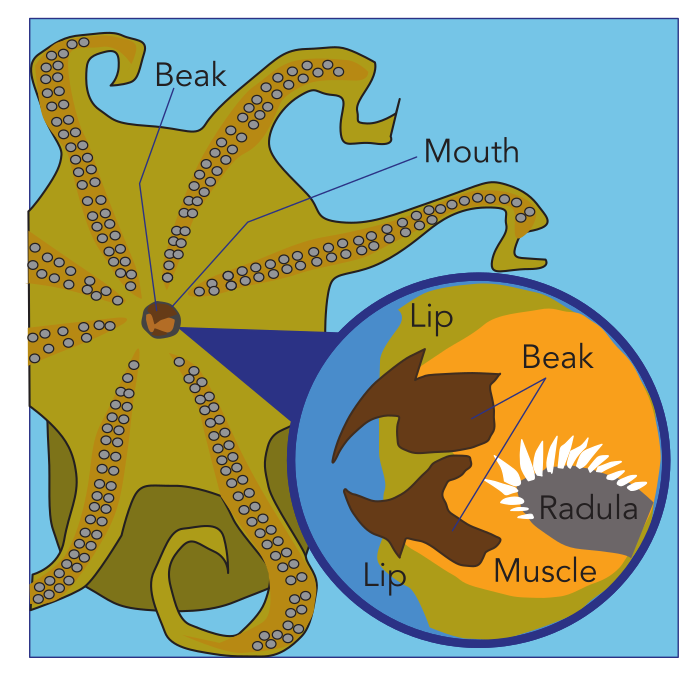

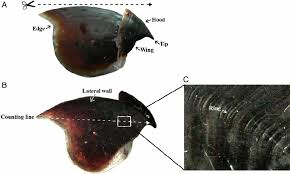

# Variable Selection

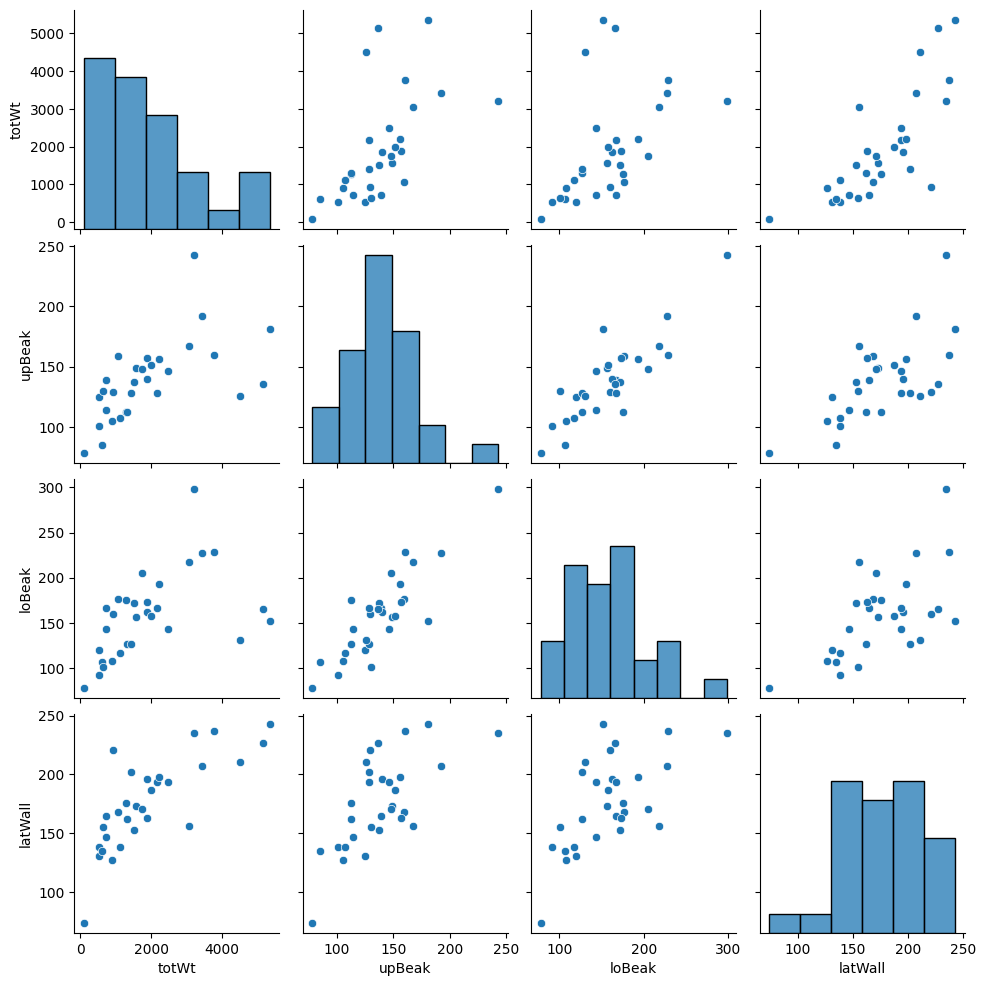

In [4]:
#pairplot to ensure data is good.
#OMG there are patterns!!!!! Data looks somewhat linear but maybe exponential...
sns.pairplot(oct)

TotWt has a pretty linear correlation with each variable in the pairplot but it seems based on the patterns that lateral wall and upper beak will be the best variable predictors because while both have outliers they are less distant from the rest of the data than lower beak.

This could be becuase according to Cambridge upper beak measurements are usually better at predicting age while lower beak tends to be better at predicting diet.

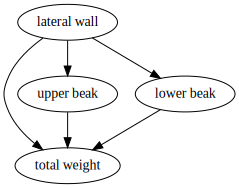

In [5]:
dag_oct = gv.Digraph(comment='oct_dag') #penguin

dag_oct.node('T', 'total weight')
dag_oct.node('U','upper beak')
dag_oct.node('L','lower beak')
dag_oct.node('W','lateral wall')


dag_oct.edges(['UT', 'LT', 'WT', 'WU', 'WL'])

dag_oct

Based on my causal diagram I am going to try interacting upBeak with latWall and loBeak with latWall.

In [ ]:
!pip install bambi

In [7]:
import bambi as bmb

In [8]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

Try Gausian as default distribution.

In [9]:
priors ={"latWall" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTG_bmb = bmb.Model("totWt ~ latWall", oct, family = "gaussian", priors=priors)

In [ ]:
idata_WTG_bmb = model_WTG_bmb.fit(idata_kwargs={"log_likelihood":True})

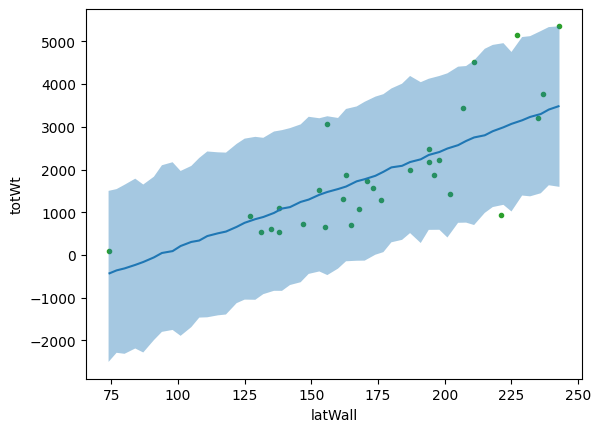

In [11]:
bmb.interpret.plot_predictions(model_WTG_bmb, idata_WTG_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

This doesn't seem to be modeling the data very well. The data seems to follow a bit more of a curve so I am going to give negative binomial a try.

In [12]:
priors ={"latWall" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTN_bmb = bmb.Model("totWt ~ latWall", oct, family = "negativebinomial", priors=priors)

In [ ]:
idata_WTN_bmb = model_WTN_bmb.fit(idata_kwargs={"log_likelihood":True})

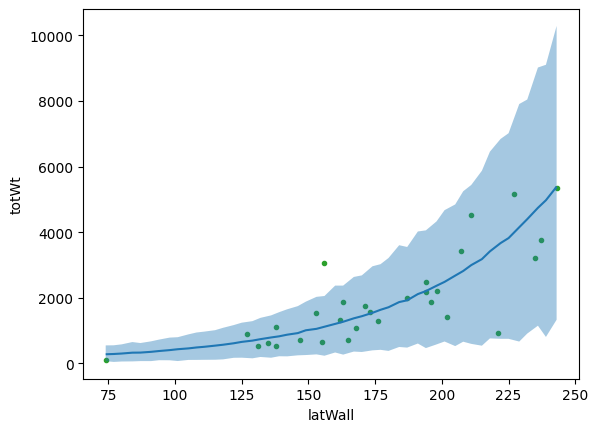

In [14]:
bmb.interpret.plot_predictions(model_WTN_bmb, idata_WTN_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

Ok so this model looks a pretty good but negative binomial is counting total weight as discrete points (non-continuous) but I tried gamma and it requires too much work so were going with negativebinomial from now on.

Lets try with multiple variables now!

In [23]:
priors ={"latWall + upBeak" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTU_bmb = bmb.Model("totWt ~ latWall + upBeak", oct, family = "negativebinomial", priors=priors)

In [ ]:
idata_WTU_bmb = model_WTU_bmb.fit(idata_kwargs={"log_likelihood":True})

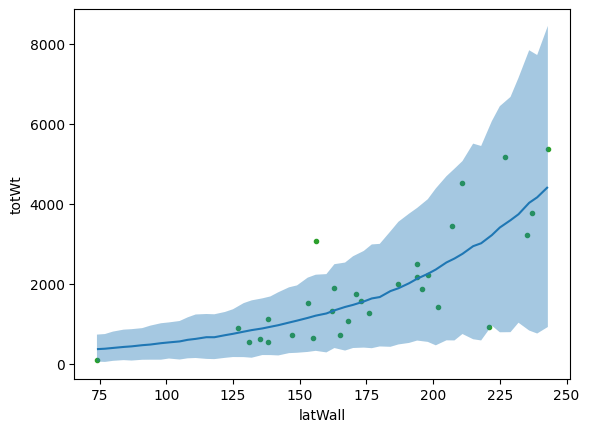

In [17]:
bmb.interpret.plot_predictions(model_WTU_bmb, idata_WTU_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

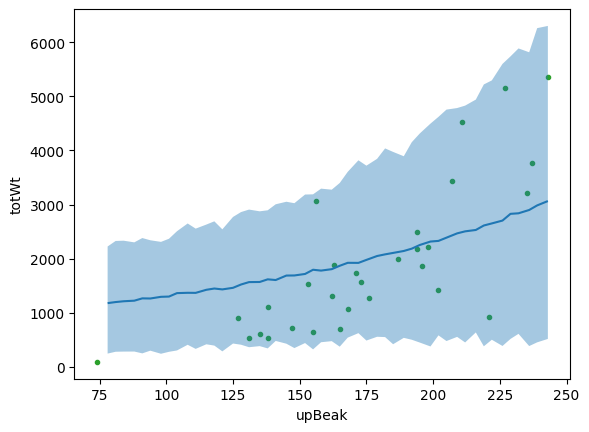

In [18]:
bmb.interpret.plot_predictions(model_WTU_bmb, idata_WTU_bmb, "upBeak", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

Ok it seems like upBeak is a much worse predictor than latWall.

In [19]:
priors ={"latWall + loBeak" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTL_bmb = bmb.Model("totWt ~ latWall + loBeak", oct, family = "negativebinomial", priors=priors)

In [ ]:
idata_WTL_bmb = model_WTL_bmb.fit(idata_kwargs={"log_likelihood":True}, tune=1999, draws=1999, chains=2, target_accept=0.95)

This was the work of Gemini and me and I have no idea what this changed but it wasn't working and now it does so I'm leaving it alone.

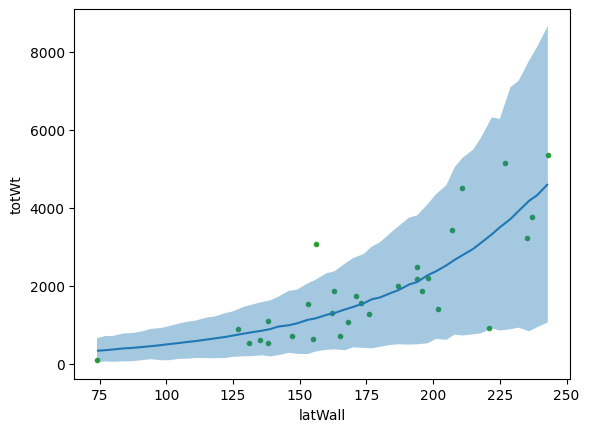

In [21]:
bmb.interpret.plot_predictions(model_WTL_bmb, idata_WTL_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

Using both loBeak and latWall as predictors seemed to work okay but I want to give all three a try.

In [27]:
priors ={"latWall + loBeak + upBeak" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTLU_bmb = bmb.Model("totWt ~ latWall + loBeak + upBeak", oct, family = "negativebinomial", priors=priors)

In [ ]:
idata_WTLU_bmb = model_WTLU_bmb.fit(idata_kwargs={"log_likelihood":True})

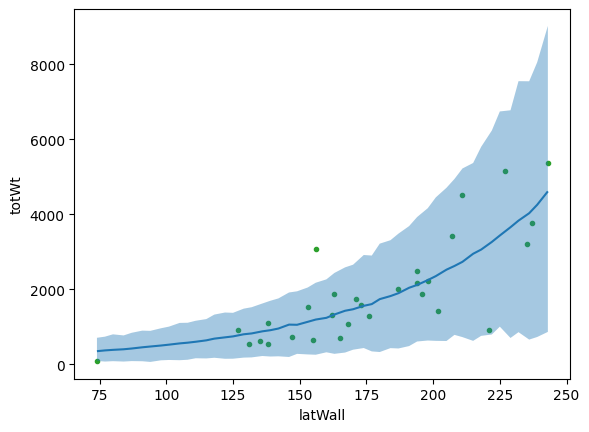

In [34]:
bmb.interpret.plot_predictions(model_WTLU_bmb, idata_WTLU_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

This looks pretty good! Except for that outlier. I'll do one last model now with all variables and their interactions.

In [42]:
priors ={"latWall + latWall*upBeak + latWall*loBeak" : bmb.Prior("Normal", mu=0,sigma=10), "alpha" : bmb.Prior("Normal",sigma=10)}
model_WTLUI_bmb = bmb.Model("totWt ~ latWall + latWall*upBeak + latWall*loBeak", oct, family = "negativebinomial", priors=priors)

In [ ]:
idata_WTLUI_bmb = model_WTLUI_bmb.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
bmb.interpret.plot_predictions(model_WTLUI_bmb, idata_WTLUI_bmb, "latWall", pps=True)
plt.plot(oct.latWall, oct.totWt, "C2.", zorder=-3)

Ok so I tried a few different formats but colab doesn't like my interactions so I am skipping them and comparing the models.

# Time to Compare!

In [ ]:
cmp_df = az.compare ({
    'Gausian': idata_WTG_bmb,
    'Negative Binomial': idata_WTN_bmb,
    'Latwall, upbeak': idata_WTU_bmb,
    'Latwall, lobeak': idata_WTL_bmb,
    'Latwall, lobeak, upbeak': idata_WTLU_bmb,
})

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

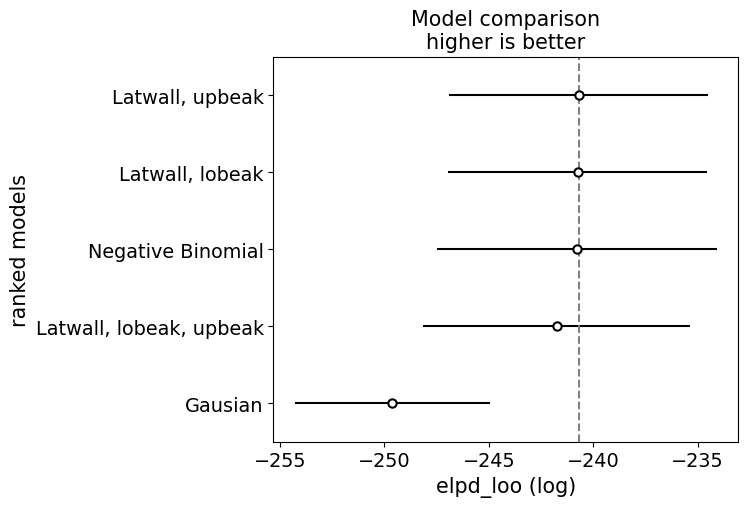

In [46]:
az.plot_compare(cmp_df)

# Analysis

Based on the elpd_loo latwall is the best predictor and latwall in conjunction with lobeak or upbeak individually preforms the best. Gausian being the worst makes complete sense (the line barely modeled any data) but I expected it would be much worse. This leads me to believe all of my models are okay and equally so. Though I am quite shocked that all three preformed noticably worse than the rest because in looking at the model I thought it was virtually the same. It probably would have preformed better if I had done interactions between them but colab was not working with me in that area.  